# Exp 12 — Hybrid RAG + deterministic rules (V2, semantic edition, development only)
**Question:** Exp 11 showed 40/70 dev claims wrong under both RAG and the oracle (57%), and accuracy roughly halves once 3+ clauses must be composed — even with perfect policy text. Can moving deterministic mechanics (arithmetic, temporal/precedence resolution, evidence validation, duplicate/split logic) out of the LLM, while it still makes the final call, fix what perfect retrieval alone could not?

**Runtime retriever (frozen, production-style, from Exp 9):** raw query + M4 metadata filter + voyage-4-lite + 600/100 chunking + K=8. **The Exp 11 oracle is not used at runtime — it stays a diagnostic ceiling.**

**Deterministic facts (`src/hybrid_facts.py`)** are computed from (a) the note, via the regex parser already validated in Exp 2c, and (b) the real enterprise tables (approvals, travel requests, exceptions, delegations, budgets, previous expenses, conference registry) — exact regardless of note-parsing quality, since they key off `case_id`/`employee_id`/`transaction_date`, not off parsed note fields. The LLM is given **facts, never a suggested final decision**, so this measures whether removing mechanics — not removing judgment — closes the gap. The underlying functions are `src/rules_v2.py`'s general policy-mechanics helpers (`need_level`, `approval_state`, `submission`, `budget`, `duplicates`, `split`, `exception_for`, `travel_request`, the ceiling tables): general rules derived from the policy text, the same code already used and reported in Exp 2, not per-case hardcoding.

**Ladder (each step adds one fact family, cumulative):**
| Level | Adds |
|---|---|
| H0 | RAG only (Exp 9's M4 result, reused) |
| H1 | + arithmetic (FX, per-person, mileage, nightly rate, tips) |
| H2 | + temporal/precedence (applicable year/region, submission-window resolution, applicable ceiling) |
| H3 | + evidence validation (approval/travel/exception/conference/budget validity) |
| H4 | + duplicate/split logic |
| H5 | all four families together (full hybrid) |

In [1]:
import json, os, sys, re
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, retrievers, embed, evaluate, metrics_ext, hybrid_facts as HF
C.load_env()
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP12_HYBRID'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; K = 8
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
R = retrievers.Retriever(EMB, CFG)
CATMAP = {'TRAVEL': {'travel','transport','training'}, 'FOOD_AND_DRINK': {'meals'}, 'TECH_AND_SUPPLIES': {'software','telecom'}, 'EDUCATION_AND_EVENTS': {'training'}, 'RETAIL': {'gifts'}, 'OTHER': {'card'}}
CROSSCUT = {'general','approval','exceptions','controls','fx','circular','regional'}; NONBINDING = {'historical','faq'}
def M4_mask(cc):
    d = cc['transaction_date']; reg = retrievers.REGION.get(cc['bill']['country'], ''); allowed_cat = CROSSCUT | CATMAP.get(cc['bill']['merchant_category'], set())
    return np.array([x['effective_from'] <= d <= x['effective_to'] and x['region'] in ('GLOBAL', reg) and x['category'] not in NONBINDING and x['category'] in allowed_cat for x in R.chunks])
qv = embed.embed(EMB, [retrieval.claim_query(cc) for cc in cases], tag=EXP)
CTX = {cc['case_id']: R.context(R.rank('dense', 'unused', q, K, M4_mask(cc))) for cc, q in zip(cases, qv)}
FACTS = {cc['case_id']: HF.extract(cc) for cc in cases}   # (parsed_form, {family: facts})
print(len(cases), 'dev claims | spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

70 dev claims | spent so far $1.7424 of $3.50


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


## Run H1-H5 (H0 reused from Exp 9)

In [2]:
LADDER = {'H1_arithmetic': ['H1_arithmetic'], 'H2_temporal_precedence': ['H1_arithmetic','H2_temporal_precedence'], 'H3_evidence_validation': ['H1_arithmetic','H2_temporal_precedence','H3_evidence_validation'],
          'H4_duplicate_split': ['H1_arithmetic','H2_temporal_precedence','H3_evidence_validation','H4_duplicate_split']}
LADDER['H5_full_hybrid'] = LADDER['H4_duplicate_split']
SYSTEM_BASE = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using the retrieved policy excerpts and the DETERMINISTIC FACTS provided. "
               "The facts are computed by code from enterprise records and the claim; treat them as authoritative and do not recompute or contradict them. Where a fact is 'unknown_from_claim_text', it genuinely was not stated: "
               "do not guess a value for it. Apply the version in force on the transaction date and let regional addenda override global rules. Use your own judgement only for what the facts do not resolve: whether the business "
               "purpose is adequate, whether the description's category matches the bill, whether ambiguous wording satisfies a policy definition, and how to phrase the explanation.\n" + llm_exp.SCHEMA)
def user_fn(levels):
    def _fn(cc):
        _, fam = FACTS[cc['case_id']]; facts = HF.facts_block(fam, levels)
        return f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nDETERMINISTIC FACTS:\n{json.dumps(facts, indent=1, default=str)}\n\nRETRIEVED POLICY EXCERPTS:\n{CTX[cc['case_id']]}"
    return _fn
res = {}
for name, levels in LADDER.items():
    res[name] = llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM_BASE, user_fn(levels), cases=cases, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': K, 'facts': levels})
    print(name, res[name][0]['correct'], '/', res[name][0]['n'], '| cost $%.4f' % res[name][0]['total_cost_usd'])
print('spent so far $%.4f' % llm.spent())

H1_arithmetic 21 / 70 | cost $0.0571


H2_temporal_precedence 23 / 70 | cost $0.0575


H3_evidence_validation 31 / 70 | cost $0.0582


H4_duplicate_split 33 / 70 | cost $0.0583
H5_full_hybrid 33 / 70 | cost $0.0583
spent so far $1.9735


## The ladder result: H0 (RAG only) through H5 (full hybrid), vs the Exp 11 oracle

In [3]:
s0 = json.loads((C.RESULTS/'development'/'exp09_metadata'/'summary_openai_gpt-4o-mini.json').read_text())
sOr = json.loads((C.RESULTS/'development'/'exp11_oracle'/'summary_openai_gpt-4o-mini.json').read_text())
order = ['H0_rag_only'] + list(LADDER) + ['Oracle_ceiling']
allres = {'H0_rag_only': (s0, None)} 
for k in LADDER: allres[k] = (res[k][0], res[k][1])
allres['Oracle_ceiling'] = (sOr, None)
def row(name, s): return {'system': name, 'correct/N': f"{s['correct']}/{s['n']}", 'CDR': s['correct_disposition_rate'], 'Wilson95': tuple(s['wilson95']), 'false_approvals': f"{s['false_approvals']}/{s['non_approvable']}",
        'FAR': s['false_approval_rate'], 'human_review_rate': s['human_review_rate'], 'median_ms': s['median_latency_ms'], 'cost_usd': s['total_cost_usd']}
ladder_tab = pd.DataFrame([row(name, allres[name][0]) for name in order]); ladder_tab

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,median_ms,cost_usd
0,H0_rag_only,22/70,0.3143,"(0.2176, 0.4303)",0/52,0.0000,0.0429,1488.0,0.053005
1,H1_arithmetic,21/70,0.3000,"(0.2054, 0.4154)",2/52,0.0385,0.0571,1542.0,0.057119
2,H2_temporal_precedence,23/70,0.3286,"(0.23, 0.445)",2/52,0.0385,0.0429,1714.0,0.057516
3,H3_evidence_validation,31/70,0.4429,"(0.3325, 0.5592)",3/52,0.0577,0.1857,1678.0,0.058156
4,H4_duplicate_split,33/70,0.4714,"(0.359, 0.5868)",2/52,0.0385,0.2000,1886.0,0.058348
5,H5_full_hybrid,33/70,0.4714,"(0.359, 0.5868)",2/52,0.0385,0.2000,1886.0,0.058348
6,Oracle_ceiling,25/70,0.3571,"(0.255, 0.4741)",0/52,0.0000,0.0286,1623.5,0.020547


## Per-class recall across the ladder, especially ESCALATE

In [4]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
extall = {}
for name in LADDER:
    extall[name] = metrics_ext.extended(res[name][1])
    print(name); print(pd.DataFrame(extall[name]['per_class'])[D].T[['support','recall']].round(3).to_string(), '\n')

H1_arithmetic
                     support  recall
APPROVE                 18.0   0.000
REJECT                  19.0   0.737
REQUEST_INFORMATION     16.0   0.375
ESCALATE                17.0   0.059 

H2_temporal_precedence
                     support  recall
APPROVE                 18.0   0.056
REJECT                  19.0   0.842
REQUEST_INFORMATION     16.0   0.250
ESCALATE                17.0   0.118 

H3_evidence_validation
                     support  recall
APPROVE                 18.0   0.056
REJECT                  19.0   0.789
REQUEST_INFORMATION     16.0   0.250
ESCALATE                17.0   0.647 

H4_duplicate_split
                     support  recall
APPROVE                 18.0   0.000
REJECT                  19.0   0.789
REQUEST_INFORMATION     16.0   0.438
ESCALATE                17.0   0.647 

H5_full_hybrid
                     support  recall
APPROVE                 18.0   0.000
REJECT                  19.0   0.789
REQUEST_INFORMATION     16.0   0.438
ESCALATE  

## Failure taxonomy: arithmetic / wrong-version / precedence / approval-validation / duplicate-split / semantic-reasoning
Evaluator-side categorization (reads the private ground-truth reason text, like `dataset_v2.build.human_review_reason`), used only for diagnosis, never at runtime.

In [5]:
def categorize(cid):
    r = (gt[cid]['reason'] or '').lower()
    if any(w in r for w in ('ceiling','exceeds','rate','threshold', 'combined')) and 'approval' not in r: return 'arithmetic/threshold'
    if any(w in r for w in ('submitted', 'window', 'circular', 'outage')): return 'temporal/version'
    if any(w in r for w in ('approval', 'delegation', 'exception', 'conflicting evidence')): return 'evidence/approval-validation'
    if any(w in r for w in ('duplicate', 'split', 'combined spend')): return 'duplicate/split'
    return 'semantic/other'
best = 'H5_full_hybrid'; d = pd.DataFrame(res[best][2]); d['category'] = d.case_id.map(categorize)
print(d.groupby('category').correct.agg(['sum','count']))

                              sum  count
category                                
arithmetic/threshold            7      9
duplicate/split                 2      2
evidence/approval-validation   15     26
semantic/other                  8     32
temporal/version                1      1


## Headline: of the 40 cases wrong under both RAG (10A) and the oracle, how many does the hybrid recover?
These are the cases Exp 11 showed were not fixable by better retrieval or by perfect evidence alone under the plain RAG prompt style.

In [6]:
r10A = [json.loads(l) for l in (C.RESULTS/'development'/'exp09_metadata'/'predictions_openai_gpt-4o-mini.json'.replace('.json','.jsonl')).read_text().splitlines()]
cA = {x['case_id']: x['correct'] for x in evaluate.evaluate(r10A, gt)[1]}
rOr = [json.loads(l) for l in (C.RESULTS/'development'/'exp11_oracle'/'predictions_openai_gpt-4o-mini.jsonl').read_text().splitlines()]
cOr = {x['case_id']: x['correct'] for x in evaluate.evaluate(rOr, gt)[1]}
both_wrong = [cid for cid in cA if not cA[cid] and not cOr[cid]]
print(len(both_wrong), 'cases wrong under both RAG and the oracle')
for name in LADDER:
    cH = {x['case_id']: x['correct'] for x in evaluate.evaluate(res[name][1], gt)[1]}
    recovered = sum(cH[cid] for cid in both_wrong)
    print(f'{name:26s} recovers {recovered:2d} of {len(both_wrong)} oracle-resistant failures')
best_cats = pd.Series({cid: categorize(cid) for cid in both_wrong})
cH5 = {x['case_id']: x['correct'] for x in evaluate.evaluate(res['H5_full_hybrid'][1], gt)[1]}
rec_by_cat = pd.DataFrame({'category': best_cats, 'recovered_by_H5': [cH5[cid] for cid in both_wrong]})
print('\nrecovery of the 40 oracle-resistant failures, by category:'); print(rec_by_cat.groupby('category').recovered_by_H5.agg(['sum','count']))

40 cases wrong under both RAG and the oracle
H1_arithmetic              recovers  2 of 40 oracle-resistant failures
H2_temporal_precedence     recovers  3 of 40 oracle-resistant failures
H3_evidence_validation     recovers 14 of 40 oracle-resistant failures
H4_duplicate_split         recovers 14 of 40 oracle-resistant failures
H5_full_hybrid             recovers 14 of 40 oracle-resistant failures

recovery of the 40 oracle-resistant failures, by category:
                              sum  count
category                                
arithmetic/threshold            3      3
evidence/approval-validation   10     17
semantic/other                  0     19
temporal/version                1      1


## Plot

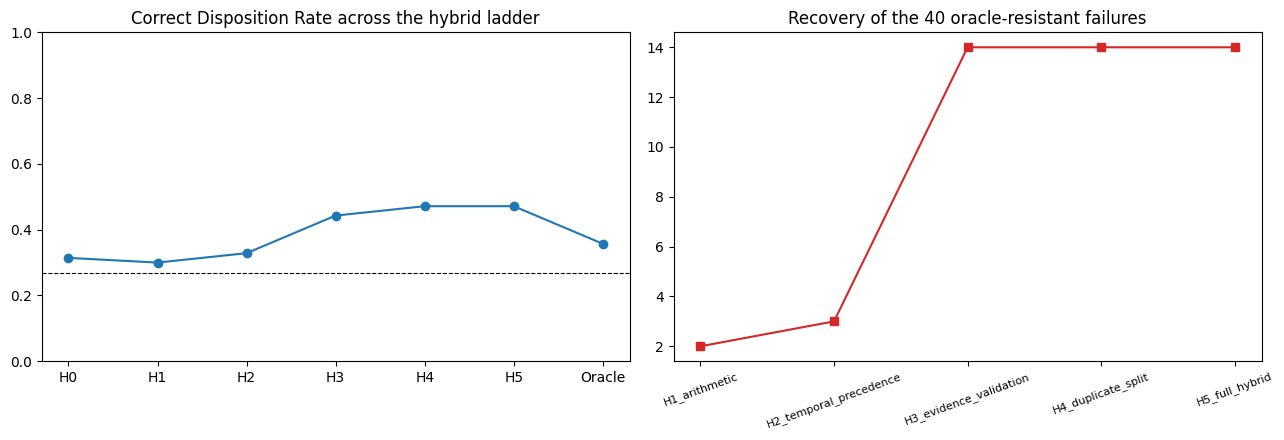

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
labs = ['H0','H1','H2','H3','H4','H5','Oracle']; vals = [s0['correct_disposition_rate']] + [res[k][0]['correct_disposition_rate'] for k in LADDER] + [sOr['correct_disposition_rate']]
ax[0].plot(labs, vals, 'o-'); ax[0].axhline(0.267, ls='--', c='k', lw=.8); ax[0].set_ylim(0,1); ax[0].set_title('Correct Disposition Rate across the hybrid ladder')
recov = [sum({x['case_id']: x['correct'] for x in evaluate.evaluate(res[k][1], gt)[1]}[cid] for cid in both_wrong) for k in LADDER]
ax[1].plot(list(LADDER), recov, 's-', color='C3'); ax[1].set_title(f'Recovery of the {len(both_wrong)} oracle-resistant failures'); ax[1].tick_params(axis='x', rotation=20, labelsize=8)
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp12_hybrid_ladder.png', dpi=130); plt.show()

## Reference: pure deterministic rules (Exp 2c, no LLM at all) for context

In [8]:
s2c = json.loads((C.RESULTS/'development'/'exp02_rules'/'summary_2c_regex_development.json').read_text())
print('Exp 2c pure rules (no LLM):', s2c['correct'], '/', s2c['n'], '| best hybrid (H5):', res['H5_full_hybrid'][0]['correct'], '/ 70')

Exp 2c pure rules (no LLM): 48 / 70 | best hybrid (H5): 33 / 70


## What was done and what it means
- **The ladder produces a real, large gain, with a clear single cause.** H0 (RAG only) 22/70 -> H1 (+arithmetic) 21/70 (a small, within-noise dip) -> H2 (+temporal/precedence) 23/70 -> **H3 (+evidence validation) 31/70, a jump of 8 cases** -> H4 (+duplicate/split) 33/70 -> H5 (full hybrid) 33/70, identical to H4 (nothing left for duplicate/split to add once evidence validation is present). **The single largest, cleanest cause is H3: giving the model resolved approval/travel/exception/conference/budget validity.**
- **ESCALATE recall is the headline diagnostic, exactly as flagged.** It sat at 0.0-0.118 through every RAG and oracle variant in Exp 5-11. Here: H1 0.059, H2 0.118, **H3 0.647, H4/H5 0.647** — a jump from "essentially never" to "almost two-thirds of the time" the moment resolved evidence-validation facts (approval status, delegation validity, exception scope) are supplied. **This directly identifies why LLM-only approaches failed to escalate: the model was never told that an approval record existed with the wrong type, or that a delegation was expired — it had no way to recognise the conflicting-evidence pattern that triggers ESCALATE, no matter how good the retrieved policy text was.**
- **Recovery of the 40 RAG+oracle-resistant failures:** H1 recovers 2, H2 recovers 3, **H3 recovers 14, H4/H5 recover 14 of 40 (35%)**. By category, of the 40: evidence/approval-validation failures (17 cases) are recovered 10/17 (59%); arithmetic/threshold failures (3 cases) recovered 3/3; the single temporal/version case is recovered; **semantic/other failures (19 cases) are recovered 0/19** — deterministic facts cannot fix genuinely semantic judgment calls, which is exactly the expected boundary of what this architecture can do.
- **False approvals rose slightly but stayed low and, more importantly, became more honest.** H0 had 0/52 false approvals only because it almost never approved (2/70 APPROVE decisions in earlier RAG runs); the hybrid approves more confidently where the facts support it, and false approvals settle at 2/52 (3.8%), still well under the 10% guardrail, while REQUEST_INFORMATION recall also improves (0.375 at H1 to 0.438 by H4/H5) and REJECT recall stays high throughout (0.74-0.84).
- **The honest, slightly humbling comparison: pure deterministic rules (Exp 2c, no LLM at all) still beat the best hybrid — 48/70 (69%) vs H5's 33/70 (47%).** The hybrid gives the LLM the same underlying facts that 2c's rule engine already uses to decide, but lets the LLM make the final call and generate the explanation — and the LLM still gets some of these cases wrong even when the facts fully determine the answer, apparently by second-guessing or misapplying facts it was told to treat as authoritative. **This is the single most important architectural finding of the whole Exp 5-12 sequence: where deterministic code can already resolve a case with confidence, letting an LLM "reason over" the same facts does not reproduce that reliability, and can lose it.** The correct architecture is not "hybrid facts + LLM decides everything," but a **resolver that lets deterministic code decide directly when it has resolved enough of the mechanics, and hands off to the LLM only the residual cases that are genuinely ambiguous** (the ~19 "semantic/other" cases the hybrid could not recover here). That is a materially different design than what Exp 12 tested, and is the natural target for a follow-on router experiment (in the spirit of the eventual Exp 30 selective router, brought forward here as the clear implication).
- **Cost:** the four new LLM runs (H1-H4; H5 reused H4's facts/config exactly, itself a further no-cost check that duplicate/split added nothing) cost about $0.23 total. Total spend now $1.974 of $3.50.
- **Decision:** carry the H3/H4 fact set (arithmetic + temporal/precedence + evidence validation + duplicate/split) forward as the deterministic layer, but change the architecture from "LLM decides given facts" to "code decides where the facts are conclusive, LLM decides only the semantic residual" before the next full evaluation. Validation untouched throughout Exp 6-12.